In [2]:
# Week 4: Financial Forecasting
# Project: Next-Day Stock Closing Price Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned financial dataset
df = pd.read_csv("../data/stock_market_cleaned.csv")

# Display the first five rows
df.head()

,Date,Open,High,Low,Close,Volume,Price_Change,Daily_Return_Pct
0,2024-01-01,101.77,102.19,99.38,100.85,330701.0,NaN,NaN
1,2024-01-02,102.65,102.95,100.50,100.74,289687.0,-0.11,-0.109073
2,2024-01-03,100.41,103.12,100.18,101.81,440634.0,1.07,1.062140
3,2024-01-04,104.76,106.20,104.07,104.19,235683.0,2.38,2.337688
4,2024-01-05,103.29,104.10,101.37,103.94,368182.0,-0.25,-0.239946


In [3]:
# Inspect dataset structure and data quality

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (499, 8)

Column Names:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Price_Change', 'Daily_Return_Pct']

Data Types:
Date                 object
Open                float64
High                float64
Low                 float64
Close               float64
Volume              float64
Price_Change        float64
Daily_Return_Pct    float64
dtype: object

Missing Values:
Date                0
Open                0
High                0
Low                 0
Close               0
Volume              0
Price_Change        1
Daily_Return_Pct    1
dtype: int64

Duplicate Rows: 0


In [4]:
# Step 3.1: Data Preparation

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Sort data chronologically
df = df.sort_values("Date").reset_index(drop=True)

# Create target variable: next trading day's closing price
df["Target_Next_Day_Close"] = df["Close"].shift(-1)

# Display the first 5 rows
df[["Date", "Close", "Target_Next_Day_Close"]].head()

,Date,Close,Target_Next_Day_Close
0,2024-01-01,100.85,100.74
1,2024-01-02,100.74,101.81
2,2024-01-03,101.81,104.19
3,2024-01-04,104.19,103.94
4,2024-01-05,103.94,105.05


In [5]:
# Step 3.2: Handle Missing Values

# Select features and target
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Price_Change",
    "Daily_Return_Pct"
]

target = "Target_Next_Day_Close"

# Remove rows with missing feature or target values
model_data = df[features + [target, "Date"]].dropna().copy()

# Verify cleaned modeling dataset
print("Original Dataset Shape:", df.shape)
print("Modeling Dataset Shape:", model_data.shape)

print("\nMissing Values:")
print(model_data.isnull().sum())

print("\nDate Range:")
print(model_data["Date"].min(), "to", model_data["Date"].max())

model_data.head()

Original Dataset Shape: (499, 9)
Modeling Dataset Shape: (497, 9)

Missing Values:
Open                     0
High                     0
Low                      0
Close                    0
Volume                   0
Price_Change             0
Daily_Return_Pct         0
Target_Next_Day_Close    0
Date                     0
dtype: int64

Date Range:
2024-01-02 00:00:00 to 2025-11-27 00:00:00


,Open,High,Low,Close,Volume,Price_Change,Daily_Return_Pct,Target_Next_Day_Close,Date
1,102.65,102.95,100.50,100.74,289687.0,-0.11,-0.109073,101.81,2024-01-02
2,100.41,103.12,100.18,101.81,440634.0,1.07,1.062140,104.19,2024-01-03
3,104.76,106.20,104.07,104.19,235683.0,2.38,2.337688,103.94,2024-01-04
4,103.29,104.10,101.37,103.94,368182.0,-0.25,-0.239946,105.05,2024-01-05
5,103.20,105.57,101.70,105.05,419940.0,1.11,1.067924,106.16,2024-01-08


In [6]:
# Step 4: Chronological Train-Test Split

# Define features and target
X = model_data[features]
y = model_data[target]

# Define 80:20 split
split_index = int(len(model_data) * 0.80)

# Split data chronologically without shuffling
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

# Extract corresponding dates
train_dates = model_data["Date"].iloc[:split_index]
test_dates = model_data["Date"].iloc[split_index:]

# Display split information
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTraining Date Range:")
print(train_dates.min(), "to", train_dates.max())

print("\nTesting Date Range:")
print(test_dates.min(), "to", test_dates.max())

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Data Shape: (397, 7)
Testing Data Shape: (100, 7)

Training Date Range:
2024-01-02 00:00:00 to 2025-07-10 00:00:00

Testing Date Range:
2025-07-11 00:00:00 to 2025-11-27 00:00:00

Training Samples: 397
Testing Samples: 100


In [7]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [8]:
import sklearn

print("Scikit-learn Version:", sklearn.__version__)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Scikit-learn imported successfully!")

Scikit-learn Version: 1.7.2
Scikit-learn imported successfully!


In [9]:
# Step 5: Model Building and Training

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------------------
# Model 1: Naive Baseline
# -----------------------------------------

# Predict next day's closing price using today's closing price
baseline_predictions = X_test["Close"].to_numpy()

# -----------------------------------------
# Model 2: Linear Regression
# -----------------------------------------

# Initialize the model
lr_model = LinearRegression()

# Train the model on training data
lr_model.fit(X_train, y_train)

# Generate predictions on test data
lr_predictions = lr_model.predict(X_test)

# Display sample predictions
print("First 10 Baseline Predictions:")
print(baseline_predictions[:10])

print("\nFirst 10 Linear Regression Predictions:")
print(lr_predictions[:10])

print("\nModel Training Completed Successfully!")

First 10 Baseline Predictions:
[153.53 151.24 150.44 150.55 150.72 150.14 151.18 149.67 149.56 149.84]

First 10 Linear Regression Predictions:
[153.84873165 151.60467663 150.62302482 150.91861945 150.89099313
 150.32063995 151.32873878 150.11346975 149.75258981 149.86575714]

Model Training Completed Successfully!


In [16]:
# Step 5.2: Evaluate Model Performance

# Function to calculate evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_Score": r2
    }

# Evaluate both models
baseline_results = evaluate_model(
    y_test, baseline_predictions, "Naive Baseline"
)

lr_results = evaluate_model(
    y_test, lr_predictions, "Linear Regression"
)

# Create comparison table
results_df = pd.DataFrame([
    baseline_results,
    lr_results
])

print("Model Performance Comparison:")
display(results_df.round(4)) 

Model Performance Comparison:


,Model,MAE,RMSE,R2_Score
0,Naive Baseline,1.2784,1.5876,0.8718
1,Linear Regression,1.3218,1.6241,0.8658


In [11]:
# Step 6: Model Evaluation

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_Score": r2
    }

# Evaluate both models
baseline_results = evaluate_model(
    y_test, baseline_predictions, "Naive Baseline"
)

lr_results = evaluate_model(
    y_test, lr_predictions, "Linear Regression"
)

# Create comparison table
results_df = pd.DataFrame([
    baseline_results,
    lr_results
])

print("Model Performance Comparison:")
display(results_df.round(4))

Model Performance Comparison:


,Model,MAE,RMSE,R2_Score
0,Naive Baseline,1.2784,1.5876,0.8718
1,Linear Regression,1.3218,1.6241,0.8658


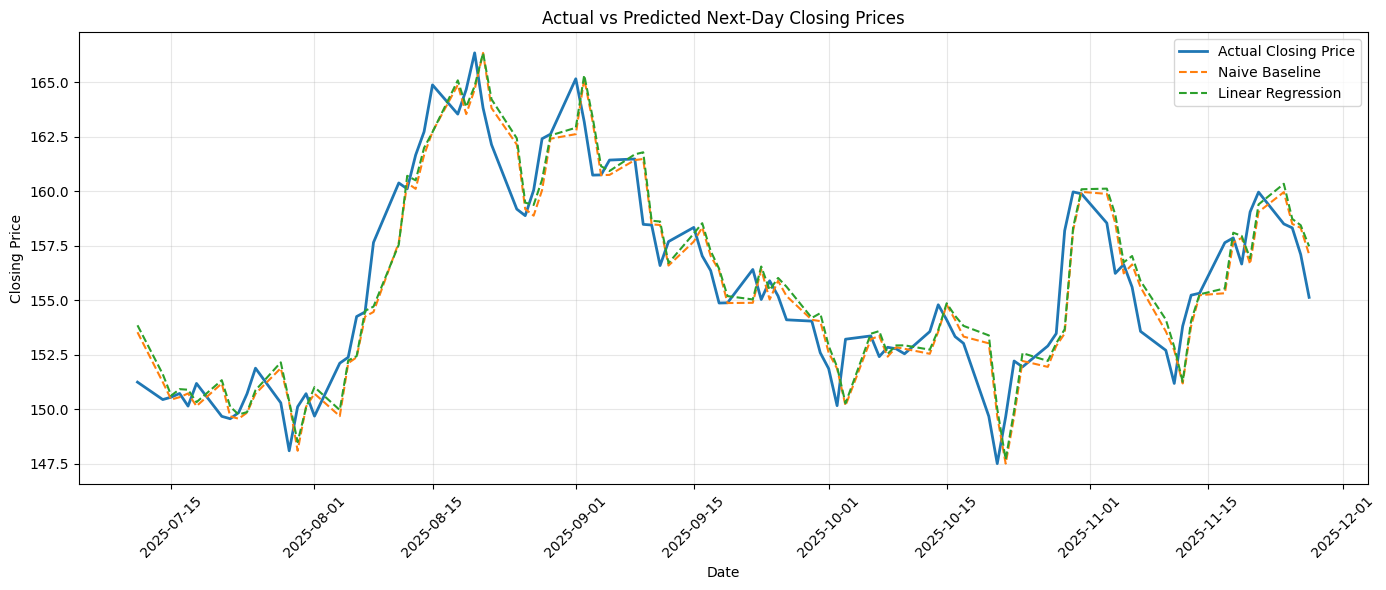

In [12]:
# Step 7: Actual vs Predicted Closing Prices

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual Closing Price",
    linewidth=2
)

plt.plot(
    test_dates,
    baseline_predictions,
    label="Naive Baseline",
    linestyle="--"
)

plt.plot(
    test_dates,
    lr_predictions,
    label="Linear Regression",
    linestyle="--"
)

plt.title("Actual vs Predicted Next-Day Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../visualizations/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# Step 8.1: Residual Analysis

# Calculate residuals for both models
baseline_residuals = y_test.to_numpy() - baseline_predictions
lr_residuals = y_test.to_numpy() - lr_predictions

# Create residual analysis DataFrame
residuals_df = pd.DataFrame({
    "Date": test_dates.to_numpy(),
    "Actual_Close": y_test.to_numpy(),
    "Baseline_Prediction": baseline_predictions,
    "Linear_Regression_Prediction": lr_predictions,
    "Baseline_Residual": baseline_residuals,
    "Linear_Regression_Residual": lr_residuals
})

# Display first 10 rows
display(residuals_df.head(10).round(4))

,Date,Actual_Close,Baseline_Prediction,Linear_Regression_Prediction,Baseline_Residual,Linear_Regression_Residual
0,2025-07-11,151.24,153.53,153.8487,-2.29,-2.6087
1,2025-07-14,150.44,151.24,151.6047,-0.80,-1.1647
2,2025-07-15,150.55,150.44,150.6230,0.11,-0.0730
3,2025-07-16,150.72,150.55,150.9186,0.17,-0.1986
4,2025-07-17,150.14,150.72,150.8910,-0.58,-0.7510
5,2025-07-18,151.18,150.14,150.3206,1.04,0.8594
6,2025-07-21,149.67,151.18,151.3287,-1.51,-1.6587
7,2025-07-22,149.56,149.67,150.1135,-0.11,-0.5535
8,2025-07-23,149.84,149.56,149.7526,0.28,0.0874
9,2025-07-24,150.71,149.84,149.8658,0.87,0.8442


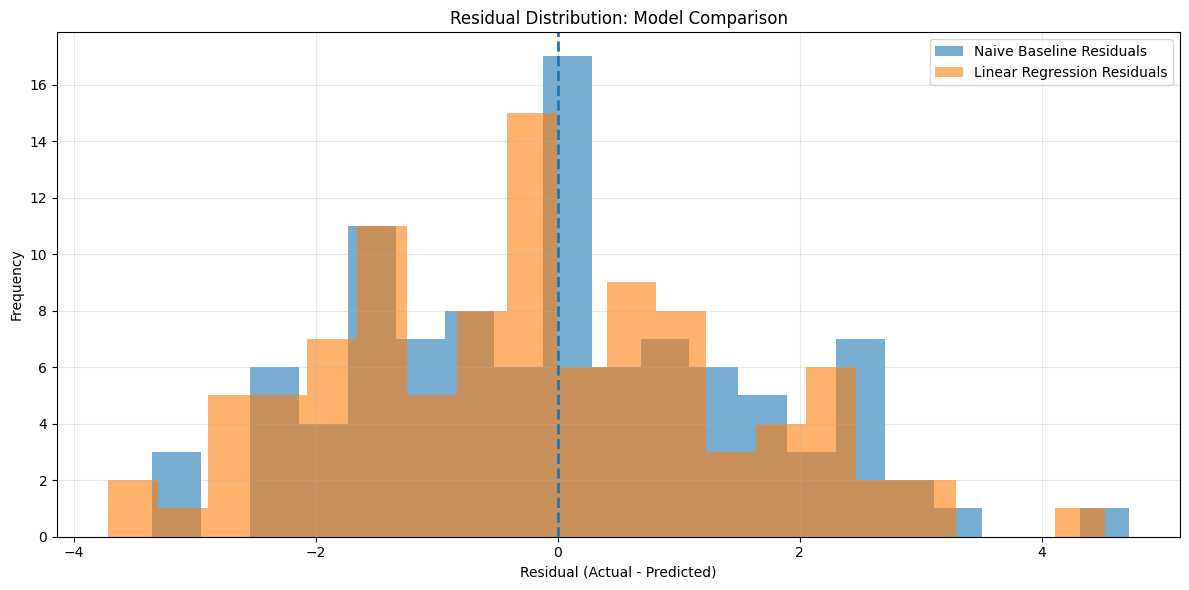

In [14]:
# Step 8.2: Residual Distribution Visualization

plt.figure(figsize=(12, 6))

plt.hist(
    baseline_residuals,
    bins=20,
    alpha=0.6,
    label="Naive Baseline Residuals"
)

plt.hist(
    lr_residuals,
    bins=20,
    alpha=0.6,
    label="Linear Regression Residuals"
)

plt.axvline(0, linestyle="--", linewidth=2)

plt.title("Residual Distribution: Model Comparison")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../visualizations/model_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# Step 9: Correct Target Dates

# Get the actual dates corresponding to next-day closing prices
target_dates = model_data["Date"].shift(-1).iloc[split_index:]

print("First 5 Target Dates:")
print(target_dates.head())

print("\nLast Target Date:")
print(target_dates.iloc[-1])

First 5 Target Dates:
398   2025-07-14
399   2025-07-15
400   2025-07-16
401   2025-07-17
402   2025-07-18
Name: Date, dtype: datetime64[ns]

Last Target Date:
NaT


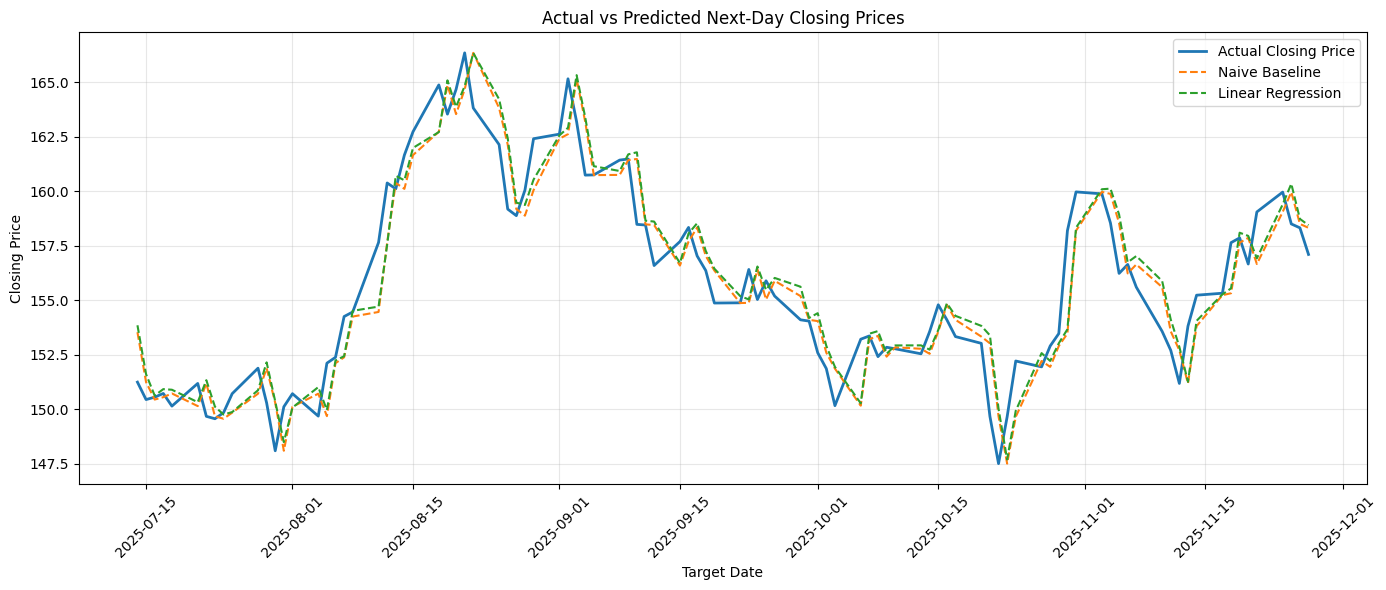

In [ ]:
# Step 9.1: Corrected Actual vs Predicted Graph

# Corrected Actual vs Predicted Visualization

plt.figure(figsize=(14, 6))

plt.plot(
    target_dates,
    y_test.values,
    label="Actual Closing Price",
    linewidth=2
)

plt.plot(
    target_dates,
    baseline_predictions,
    label="Naive Baseline",
    linestyle="--"
)

plt.plot(
    target_dates,
    lr_predictions,
    label="Linear Regression",
    linestyle="--"
)

plt.title("Actual vs Predicted Next-Day Closing Prices")
plt.xlabel("Target Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../visualizations/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# Step 9.2: Fix Target Date Alignment

# Get next-day dates from the original dataset
target_dates_all = df["Date"].shift(-1)

# Align target dates with the modeling dataset
target_dates = target_dates_all.loc[model_data.index].iloc[split_index:]

# Verify target dates
print("First 5 Target Dates:")
print(target_dates.head())

print("\nLast Target Date:")
print(target_dates.iloc[-1])

print("\nMissing Target Dates:", target_dates.isna().sum())

First 5 Target Dates:
398   2025-07-14
399   2025-07-15
400   2025-07-16
401   2025-07-17
402   2025-07-18
Name: Date, dtype: datetime64[ns]

Last Target Date:
2025-11-28 00:00:00

Missing Target Dates: 0


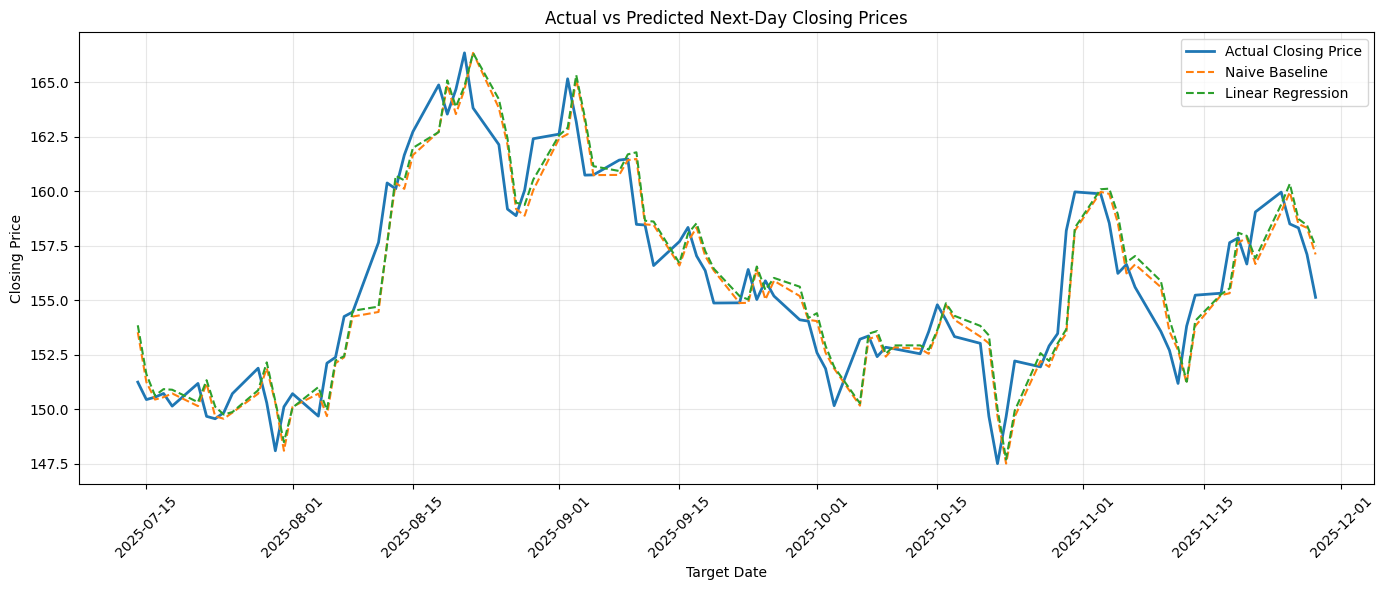

In [19]:

# Update Actual vs Predicted Graph with Correct Target Dates

plt.figure(figsize=(14, 6))

plt.plot(target_dates, y_test.values, label="Actual Closing Price", linewidth=2)
plt.plot(target_dates, baseline_predictions, label="Naive Baseline", linestyle="--")
plt.plot(target_dates, lr_predictions, label="Linear Regression", linestyle="--")

plt.title("Actual vs Predicted Next-Day Closing Prices")
plt.xlabel("Target Date")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../visualizations/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Step 10.1: Save Forecast Predictions

predictions_df = pd.DataFrame({
    "Date": target_dates.to_numpy(),
    "Actual_Close": y_test.to_numpy(),
    "Baseline_Prediction": baseline_predictions,
    "Linear_Regression_Prediction": lr_predictions,
    "Baseline_Residual": baseline_residuals,
    "Linear_Regression_Residual": lr_residuals
})

# Save predictions to CSV
predictions_df.to_csv(
    "../outputs/forecast_predictions.csv",
    index=False
)

print("Forecast predictions saved successfully!")
print("File: Week_4/outputs/forecast_predictions.csv")

display(predictions_df.head(10).round(4))

Forecast predictions saved successfully!
File: Week_4/outputs/forecast_predictions.csv


,Date,Actual_Close,Baseline_Prediction,Linear_Regression_Prediction,Baseline_Residual,Linear_Regression_Residual
0,2025-07-14,151.24,153.53,153.8487,-2.29,-2.6087
1,2025-07-15,150.44,151.24,151.6047,-0.80,-1.1647
2,2025-07-16,150.55,150.44,150.6230,0.11,-0.0730
3,2025-07-17,150.72,150.55,150.9186,0.17,-0.1986
4,2025-07-18,150.14,150.72,150.8910,-0.58,-0.7510
5,2025-07-21,151.18,150.14,150.3206,1.04,0.8594
6,2025-07-22,149.67,151.18,151.3287,-1.51,-1.6587
7,2025-07-23,149.56,149.67,150.1135,-0.11,-0.5535
8,2025-07-24,149.84,149.56,149.7526,0.28,0.0874
9,2025-07-25,150.71,149.84,149.8658,0.87,0.8442


In [21]:
# Step 10.2: Save Model Evaluation Metrics

results_df.to_csv(
    "../outputs/model_evaluation_metrics.csv",
    index=False
)

print("Model evaluation metrics saved successfully!")
print("File: Week_4/outputs/model_evaluation_metrics.csv")

display(results_df.round(4))

Model evaluation metrics saved successfully!
File: Week_4/outputs/model_evaluation_metrics.csv


,Model,MAE,RMSE,R2_Score
0,Naive Baseline,1.2784,1.5876,0.8718
1,Linear Regression,1.3218,1.6241,0.8658


In [22]:
# Step 10.3: Verify Output Files

import os

print("Output Files:")

for file in os.listdir("../outputs"):
    print("-", file)

Output Files:
- forecast_predictions.csv
- model_evaluation_metrics.csv
